<a href="https://colab.research.google.com/github/div652/GPT-2/blob/main/gpt2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Goal here is to set up GPT2 architecture
- reproduce results
- ability to load their model
- ability to train our own model
- We will reproduce the 124M model.
- smallest was 117M in their paper, was corrected to 124M later. see github.
- Will refer GPT3 as well, since there is not a huge departure in the architecture.
- Will implement in pytorch, but the initial code was in tensorflow.
- Their a torch implementation in huggingface, and you can load the model from here as well.
- https://huggingface.co/openai-community/gpt2


# Sources
Attention is all you need paper : https://arxiv.org/abs/1706.03762
OpenAI GPT-2 Paper : https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf
GPT2 Blogpost : https://openai.com/index/better-language-models/

OpenAI GPT-3 Paper :https://arxiv.org/pdf/2005.14165

We begin by setting up the model

In [2]:
!pip install matplotlib
!pip install tiktoken

# Imports

In [3]:
import os
import math
import time
import inspect
from dataclasses import dataclass # for GPT Config class
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import tiktoken
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [4]:
#return a torch tensor of prompt to tokens on cpu.
def get_tokens(prompt):
  enc = tiktoken.get_encoding('gpt2')
  tokens = enc.encode(prompt)
  tokens = torch.tensor(tokens, dtype = torch.long)
  return tokens
def get_text(tokens):
  enc = tiktoken.get_encoding('gpt2')
  decoded = enc.decode(tokens)
  return decoded


# Importing Trained Model to check GPT2 weights

In [5]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel
HuggingFaceModel = GPT2LMHeadModel.from_pretrained("gpt2")
HuggingFaceStateDict = HuggingFaceModel.state_dict()
for k,v in HuggingFaceStateDict.items():
  print(k,v.shape)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

## Hyper Parameter Setup

In [37]:
@dataclass
class GPTConfig:
  block_size: int=1024 # context length
  vocab_size: int= 50304 # 50,000 BPE merges, 256 bytes, 1 EOS  = 50257 but, we incrse it. 
  n_layer: int =12
  n_head: int =12
  n_embd: int =768
  lr = 3e-4
  device = "cpu"
  if torch.cuda.is_available():
    device = "cuda"
  elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
  print("Using device: %s" % device)

Using device: cuda


# Setting up the tiny-shakespeare dataset

In [38]:
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()
print(get_tokens(text[:1000]).shape, get_tokens(text[:1000]))

--2026-05-12 15:54:31--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt.1’

input.txt.1         100%[===================>]   1.06M  --.-KB/s    in 0.02s   

2026-05-12 15:54:32 (49.0 MB/s) - ‘input.txt.1’ saved [1115394/1115394]

torch.Size([285]) tensor([ 5962, 22307,    25,   198,  8421,   356,  5120,   597,  2252,    11,
         3285,   502,  2740,    13,   198,   198,  3237,    25,   198,  5248,
          461,    11,  2740,    13,   198,   198,  5962, 22307,    25,   198,
         1639,   389,   477, 12939,  2138,   284,  4656,   621,   284,  1145,
          680,    30,   198,   198,  3237,    25,   198,  4965,  56

Ok, dataset loading works fine.

Compression rate seems 28%

Creating the dataset object

This is different from What Karparthy does. he makes a batch from B*T+1 neighbouring tokens.

The strategy that I am using makes a dataset object. that gives a T sized example.

To make my batch, I use a dataloader object. this makes the batch examples that are randomly placed across the dataset.

This is slower as there is overhead of python, but learning per batch is higher, since the data is more reprseentative.

Moreover, in Karparthy's implementation, all his batches come one after another, in my case, even each batch is randomly
distrbuted. so more random learning again.

In [39]:
class TextDataset(Dataset):
    # data has to be a string .
    # config is GPTConfig object.
    def __init__(self, data, config):
        self.data = get_tokens(data)
        self.T = config.block_size
        self.vocab_size = config.vocab_size
        self.size = len(self.data) - (self.T)
        print(f"Succesfully made textdataset. Num tokens : {len(self.data)}")

    def __len__(self):
        return self.size

# Dataset returns a 1d list of tokens as a torch tensor.
    def __getitem__(self, idx):
        buf = torch.tensor(self.data[idx:idx+self.T+1])
        x = buf[:-1]
        y = buf[1:]
        return x,y

## Dataloader Factory function

In [40]:
def getDataLoader(string_data,config,batch_size):
  dataLoader= DataLoader(
    TextDataset(string_data, config),
    batch_size=batch_size,
    shuffle=True,
    num_workers=2  # In Colab, 2 is usually the sweet spot
  )
  print(f"Succesfully made DataLoader, num_examples {len(dataLoader)}")
  return dataLoader

def get_random_batch(dataloader):
    data_iter = iter(dataloader)
    x, y = next(data_iter)
    return x, y

## Setup a batch size, Make a train dataset and dataloader

In [41]:
batch_size = 16
trainDataLoader = getDataLoader(text,GPTConfig ,batch_size)

Succesfully made textdataset. Num tokens : 338025
Succesfully made DataLoader, num_examples 21063


# Implementing our own model

## Model Code

In [42]:
class CausalSelfAttention(nn.Module):
# c_attn.weight torch.Size([768, 2304])
# c_attn.bias torch.Size([2304])
# c_proj.weight torch.Size([768, 768])
# c_proj.bias torch.Size([768])
  def __init__(self,config):
    super().__init__()
    assert config.n_embd%config.n_head==0
    self.n_embd = config.n_embd
    self.n_head = config.n_head

  # using bias here because openAI used it, I don't think it is needed.
    self.c_attn = nn.Linear(self.n_embd, 3*self.n_embd)
    self.c_proj = nn.Linear(self.n_embd, self.n_embd)
    self.c_proj.NANOGPT_SCALE_INIT = 1
    # calling it mask,
    self.register_buffer("mask", torch.tril(torch.ones(config.block_size,config.block_size)).view(1,1,config.block_size,config.block_size))

  def forward(self,x):
    B,T,C = x.shape
    qkv = self.c_attn(x)
    q,k,v = torch.split(qkv, self.n_embd, dim=2)

    q = q.view(B,T,self.n_head, C//self.n_head).transpose(1,2) # B,n_h,T,n_embd/n_h
    k = k.view(B,T,self.n_head, C//self.n_head).transpose(1,2) # B,n_h,T,n_embd/n
    v = v.view(B,T,self.n_head, C//self.n_head).transpose(1,2) # B,n_h,T,n_embd/n_h

    # att = q@k.transpose(-2,-1) # B,n_h, T, T
    # att = att*((C//self.n_head)**-0.5) # scaling by head dimesion
    # att = att.masked_fill(self.mask[:,:,:T,:T]==0,float('-inf'))
    # att = F.softmax(att,dim=-1)
    # y = att@v
    y = F.scaled_dot_product_attention(q,k,v,is_causal=True)
    y = y.transpose(1,2).contiguous().view(B,T,C)
    y = self.c_proj(y)
    return y

nn.Gelu has two versions, the original version, and he approximate version calculated from tanh.

https://arxiv.org/pdf/1606.08415was deveopled the erf function which is used in torch for GELU implementation , was very slow in torch at that time. So at that time bert and gpt-2 used the tanh version in their architecutre, so we are going to use that.

Why GELU vs. RELU
- activations that ended up in the zero region had no gradient
- so there is always some contribution in the GELU case, there are not dead regions


In [43]:
class FeedForwardLayer(nn.Module):
  def __init__(self,config):
    super().__init__()
    self.c_fc = nn.Linear(config.n_embd, 4*config.n_embd)
    self.gelu = nn.GELU(approximate='tanh')
    self.c_proj = nn.Linear(4*config.n_embd, config.n_embd)
    self.c_proj.NANOGPT_SCALE_INIT = 1

  def forward(self,x):
    x = self.c_fc(x)
    x = self.gelu(x)
    x = self.c_proj(x)
    return x


Note: in the original Attention is all you need paper there was this one difference.
- Layer Norms were after Attention block and MLP . They are now before attention and MLP


In [44]:
class Block(nn.Module):
  def __init__(self,config):
    super().__init__()
    self.ln_1 = nn.LayerNorm(config.n_embd)
    self.attn = CausalSelfAttention(config)
    self.ln_2 = nn.LayerNorm(config.n_embd)
    self.mlp = FeedForwardLayer(config)

# each block is just a repeated application of map-reduce.
  def forward(self,x):
    # attention is the reduce
    x = x + self.attn(self.ln_1(x))
    # mlp is the map
    x = x + self.mlp(self.ln_2(x))
    return x

### Note on why we use no_grad while doing copy
1. Avoiding Computation Graph Overhead
By default, if sd[k] or sd_hf[k] are tensors that have requires_grad=True (which is standard for model parameters), any operation performed on them—including .copy_() or .t() (transpose)—could be tracked by the Autograd engine.

Without no_grad: PyTorch might try to build a "graph" of this operation, consuming extra memory and CPU/GPU cycles to keep track of how the data was moved.

With no_grad: You tell PyTorch, "This is just a memory-to-memory copy; don't worry about the history of these tensors."

2. Preventing "Leaf Tensor" Errors
In PyTorch, model parameters are usually leaf tensors. Autograd generally prevents you from performing "in-place" operations on leaf tensors that require gradients because it would break the ability to calculate gradients for them later.
If you tried to use .copy_() on a parameter without no_grad(), PyTorch might throw a runtime error saying:

"RuntimeError: a view of a leaf Variable that requires grad is being used in an in-place operation."

Using the no_grad context manager signals that you are intentionally modifying the values outside of the training loop.

Important observation : wte and lm_head are exactly the same ! It is a weight tieing scheecm. The idea is also present in Attention is All You Need Paper.

Intuition is that : the wte matrix takes token values and takes to semantic meaning. and the other does vice versa. the property that similar tokens must have similar weights, leads these matrices to essentially represent the same information.

wte and lm_head also make a big part of the model size ! vocab_size*n_embd.  

In [45]:
from torch.nn.modules import loss
class GPT(nn.Module):
  def __init__(self,config):
    super().__init__()
    self.config = config
    self.transformer = nn.ModuleDict({
        "wte" : nn.Embedding(config.vocab_size, config.n_embd),
        "wpe" : nn.Embedding(config.block_size, config.n_embd),
        "h" : nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
        "ln_f" : nn.LayerNorm(config.n_embd)
    })
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
    # weight sharing scheme
    self.transformer.wte.weight = self.lm_head.weight

    self.apply(self._init_weights)

  # set the bias values to 0 and weight values to be normal with sd=0.02
  # why 0.02, as this is ~ 1/sqrt(embed_dim)
  # we further scaledown the attention c_proj weights by 1/root(n)
  def _init_weights(self,module):
    if isinstance(module, nn.Linear):
      std = 0.02
      if hasattr(module, "NANOGPT_SCALE_INIT"):
        std *= (2*self.config.n_layer)**-0.5
      torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
      if module.bias is not None:
        torch.nn.init.zeros_(module.bias)
      elif isinstance(module, nn.Embedding):
        torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
# from_pretrained is a constructor that returns a GPT object initialised with
# weights form the hugging face model, based on the model_type we provide it with.
  def forward(self,x, targets=None):
    # x is a batch of tokens
    B,T = x.shape
    assert T<=self.config.block_size , f"Cannot forward sequence of length {T}, block size is {self.config.block_size}"
    pos = torch.arange(T, dtype=torch.long, device=x.device) # should be on the same device
    token_embeddings = self.transformer.wte(x) # B,T,n_embd
    position_embeddings = self.transformer.wpe(pos) # T,n_embd
    x = token_embeddings + position_embeddings # torch will broadcast along Batch dimension.
    for block in self.transformer.h:
      x = block(x)
    x = self.transformer.ln_f(x)
    logits = self.lm_head(x) # (B,T,vocab_size)

    if targets==None:
      return logits
# Important observation loss is not calculated only over the last token prediction.
# Loss is calculated over all token predictions.
# Also note that cross entropy likes 2d tensors as first input. n*probabities
# and second input is  size n, telling the correct index.
    loss = F.cross_entropy(logits.view(-1,logits.size(-1)), targets.view(-1))
    return logits, loss

  @classmethod
  def from_pretrained(cls,model_type):
    # Loads pretrained GPT-2 Model weight from hugging face
    assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
    from transformers import GPT2LMHeadModel
    print("Loading Weights from pretrained gpt: %s" % model_type)

    # n_layer, n_head and n_embd are detemrined from model type
    config_args = {
        'gpt2': dict(n_layer=12, n_head=12, n_embd=768),        # 124M params
        'gpt2-medium': dict(n_layer=24, n_head=16, n_embd=1024),# 350M params
        'gpt2-large': dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
        'gpt2-xl': dict(n_layer=48, n_head=25, n_embd=1600),    # 1558M params
    }[model_type]
    config_args['vocab_size'] = 50257 # same for all the models
    config_args['block_size'] = 1024  # same for all the models
    config = GPTConfig(**config_args)

    # our model
    model = GPT(config)
    sd = model.state_dict()
    sd_keys = sd.keys()
    print(sd_keys,sep='\n')
    sd_keys = [k for k in sd_keys if not k.endswith(".attn.mask")] # ignoring the register buffers, these are non trainable parameters

    # hugging face model
    model_hf = GPT2LMHeadModel.from_pretrained(model_type)
    sd_hf = model_hf.state_dict()
    sd_keys_hf = sd_hf.keys()
    print(sd_keys_hf,sep='\n')
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith(".attn.masked_bias")] # ignoring the register buffers, these are non trainable parameters
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith(".attn.bias")] # ignoring the register buffers, these are non trainable parameters
    transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
    # some layers in the gpt2 implementation need to transposed since they were originally written as a conv1d.
    # while we have implemented it using a vanilla Linear layer
    assert len(sd_keys)==len(sd_keys_hf),f"Model sizes do not match {len(sd_keys)} vs {len(sd_keys_hf)}"
    for k in sd_keys:
      if any(k.endswith(w) for w in transposed):
        assert sd_hf[k].shape[::-1]==sd[k].shape, f"Shapes {sd_hf[k].shape[::-1]} and {sd[k].shape} don't match for key {k}"
        with torch.no_grad():
          sd[k].copy_(sd_hf[k].t())
      else:
        #vanilla copy over the parameters
        assert sd_hf[k].shape==sd[k].shape , f"Shapes {sd_hf[k].shape} and {sd[k].shape} don't match for key {k}"
        with torch.no_grad():
          sd[k].copy_(sd_hf[k])

    return model


## Make the model object

In [46]:
# # this worked fine. Currently skipping it.
# %%script false --no-raise-error
# model = GPT.from_pretrained('gpt2')
# print("model loaded successfully")

# num_return_sequences = 5
# max_length = 30
# model.eval() # this removes things like dropouts
# model.to('cuda')
# tokens = get_tokens("Hello, I'm a language model")
# tokens = tokens.unsqueeze(0).repeat(num_return_sequences,1) # repeat along the dim1
# x = tokens.to('cuda')
# torch.manual_seed(42)
# torch.cuda.manual_seed(42)
# print(x.shape)
# while x.size(1) < max_length:
#   with torch.no_grad():
#     logits = model(x) # B,T,vocab_size
#     logits = logits[:,-1,:] # B,vocab_size. Only need the last logits
#     probs = F.softmax(logits,dim=-1)
#     # we pick only top50, so that hte model doesn't stray away into unkonwn zones. and styas in "good" zones
#     topk_probs, topk_indices = torch.topk(probs,50,dim=-1) # this is the temperature sampling essentially. we don't pick the most probable, rather we sample from the distribution
#     ix = torch.multinomial(topk_probs,1)#B,1
#     xcol = torch.gather(topk_indices,-1,ix)
#     x = torch.cat((x,xcol),dim=1)

#   # print the generated text
# for i in range(num_return_sequences):
#   tokens = x[i,:max_length].tolist()
#   print(">",get_text(tokens))

In [47]:
torch.set_float32_matmul_precision('high')
model = GPT(GPTConfig)
model = torch.compile(model)

Above results are same when we sample from the original Hugging Face model.

There is a difference when we use pipeline, don't know why.

Lets move ahead.

Next step is to train the model on our own.

# Sanity Check
Getting loss on a single batch. should be about log(vocab_size), because initial predictions would be random.
ln(50257) = 10.82

In [48]:
%%script false --no-raise-error
x,y = get_random_batch(trainDataLoader)
print(model(x,y)[1])

# Setup training
Make optimiser object, use AdamW

In [49]:
optimizer = torch.optim.AdamW(model.parameters(), GPTConfig.lr)

## Training Sanity Check : OverFit a single batch.

In [50]:
# %%script false --no-raise-error
# # Important observation here,
# # when you call .to(device), for tensors it returns a pointer, it is not stateful,
# # but for nn.Module it moves the model parameters to device
# # make a basic graph plot for this training.
# x,y = get_random_batch(trainDataLoader)
# x = x.to(GPTConfig.device)
# y = y.to(GPTConfig.device)
# model.to(GPTConfig.device)
# losses = []
# for i in range(50):
#   optimizer.zero_grad()
#   logits, loss = model(x,y)
#   loss_val = loss.item()
#   losses.append(loss_val)
#   loss.backward()
#   optimizer.step()
#   print(f"step {i}, loss : {loss_val} ")
# plt.plot(losses)
# plt.show()

/tmp/ipykernel_1774/1095872862.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  buf = torch.tensor(self.data[idx:idx+self.T+1])
/tmp/ipykernel_1774/1095872862.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  buf = torch.tensor(self.data[idx:idx+self.T+1])


epoch : 0, step : 1, loss : 10.96187973022461, dt: 17643.16ms , tok/sec: 928.63
epoch : 0, step : 2, loss : 9.508356094360352, dt: 115.47ms , tok/sec: 141894.15
epoch : 0, step : 3, loss : 8.986274719238281, dt: 116.75ms , tok/sec: 140333.76
epoch : 0, step : 4, loss : 8.794988632202148, dt: 117.60ms , tok/sec: 139324.01
epoch : 0, step : 5, loss : 8.450994491577148, dt: 117.18ms , tok/sec: 139816.11
epoch : 0, step : 6, loss : 8.227209091186523, dt: 116.85ms , tok/sec: 140209.21
epoch : 0, step : 7, loss : 8.001070022583008, dt: 117.46ms , tok/sec: 139483.79
epoch : 0, step : 8, loss : 7.828130722045898, dt: 116.80ms , tok/sec: 140269.02
epoch : 0, step : 9, loss : 7.615079879760742, dt: 118.94ms , tok/sec: 137744.47
epoch : 0, step : 10, loss : 7.380428314208984, dt: 117.62ms , tok/sec: 139290.97
epoch : 0, step : 11, loss : 7.123398780822754, dt: 117.09ms , tok/sec: 139928.85
epoch : 0, step : 12, loss : 7.057843208312988, dt: 116.79ms , tok/sec: 140280.47
epoch : 0, step : 13, loss

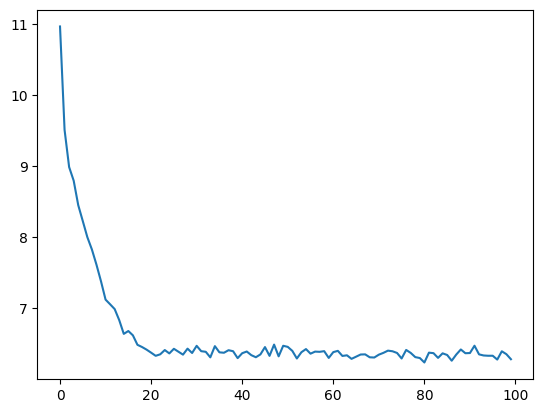

epoch : 0, step : 101, loss : 6.353788375854492, dt: 114.19ms , tok/sec: 143475.54
epoch : 0, step : 102, loss : 6.370612144470215, dt: 116.73ms , tok/sec: 140355.54
epoch : 0, step : 103, loss : 6.304739952087402, dt: 117.89ms , tok/sec: 138972.09
epoch : 0, step : 104, loss : 6.313554763793945, dt: 117.57ms , tok/sec: 139350.56
epoch : 0, step : 105, loss : 6.355116844177246, dt: 117.19ms , tok/sec: 139809.28
epoch : 0, step : 106, loss : 6.256855010986328, dt: 117.40ms , tok/sec: 139561.69
epoch : 0, step : 107, loss : 6.27687931060791, dt: 117.22ms , tok/sec: 139774.59
epoch : 0, step : 108, loss : 6.39543342590332, dt: 117.45ms , tok/sec: 139493.41
epoch : 0, step : 109, loss : 6.356328964233398, dt: 117.44ms , tok/sec: 139511.25
epoch : 0, step : 110, loss : 6.271162986755371, dt: 117.35ms , tok/sec: 139614.14
epoch : 0, step : 111, loss : 6.3623480796813965, dt: 117.59ms , tok/sec: 139337.00
epoch : 0, step : 112, loss : 6.322453498840332, dt: 117.19ms , tok/sec: 139802.17
epoch

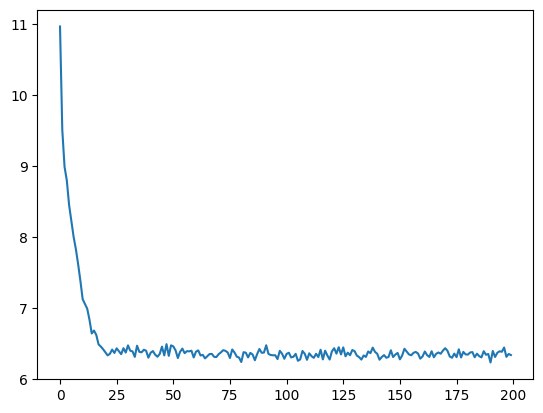

epoch : 0, step : 201, loss : 6.290948867797852, dt: 113.68ms , tok/sec: 144129.74
epoch : 0, step : 202, loss : 6.3538312911987305, dt: 117.11ms , tok/sec: 139904.35
epoch : 0, step : 203, loss : 6.335634231567383, dt: 117.19ms , tok/sec: 139802.74
epoch : 0, step : 204, loss : 6.360013961791992, dt: 117.60ms , tok/sec: 139317.51
epoch : 0, step : 205, loss : 6.323519706726074, dt: 117.51ms , tok/sec: 139428.32
epoch : 0, step : 206, loss : 6.308128356933594, dt: 117.84ms , tok/sec: 139033.11
epoch : 0, step : 207, loss : 6.357458114624023, dt: 118.15ms , tok/sec: 138672.58
epoch : 0, step : 208, loss : 6.350306510925293, dt: 117.83ms , tok/sec: 139045.77
epoch : 0, step : 209, loss : 6.36715030670166, dt: 117.23ms , tok/sec: 139755.54
epoch : 0, step : 210, loss : 6.382536888122559, dt: 117.36ms , tok/sec: 139599.39
epoch : 0, step : 211, loss : 6.256341934204102, dt: 117.79ms , tok/sec: 139091.36
epoch : 0, step : 212, loss : 6.4387054443359375, dt: 117.08ms , tok/sec: 139937.68
epo

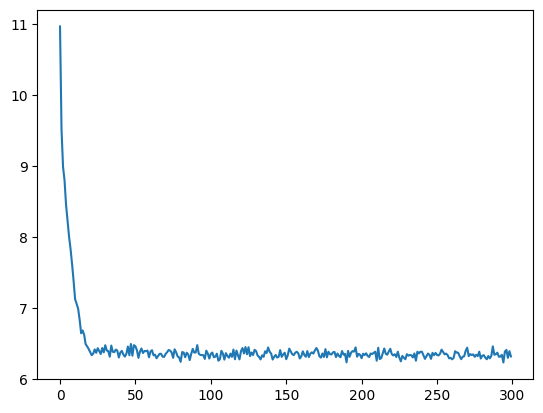

epoch : 0, step : 301, loss : 6.311514854431152, dt: 115.16ms , tok/sec: 142276.64
epoch : 0, step : 302, loss : 6.310555934906006, dt: 117.32ms , tok/sec: 139649.89
epoch : 0, step : 303, loss : 6.360001564025879, dt: 117.90ms , tok/sec: 138960.85
epoch : 0, step : 304, loss : 6.262604713439941, dt: 118.62ms , tok/sec: 138122.66
epoch : 0, step : 305, loss : 6.220467567443848, dt: 117.98ms , tok/sec: 138865.38
epoch : 0, step : 306, loss : 6.378871917724609, dt: 118.37ms , tok/sec: 138411.43
epoch : 0, step : 307, loss : 6.256102561950684, dt: 118.31ms , tok/sec: 138478.65
epoch : 0, step : 308, loss : 6.339712142944336, dt: 118.52ms , tok/sec: 138234.63
epoch : 0, step : 309, loss : 6.292839050292969, dt: 118.23ms , tok/sec: 138582.26
epoch : 0, step : 310, loss : 6.2972259521484375, dt: 118.43ms , tok/sec: 138337.59
epoch : 0, step : 311, loss : 6.2454023361206055, dt: 117.91ms , tok/sec: 138956.92
epoch : 0, step : 312, loss : 6.319255828857422, dt: 118.37ms , tok/sec: 138415.34
ep

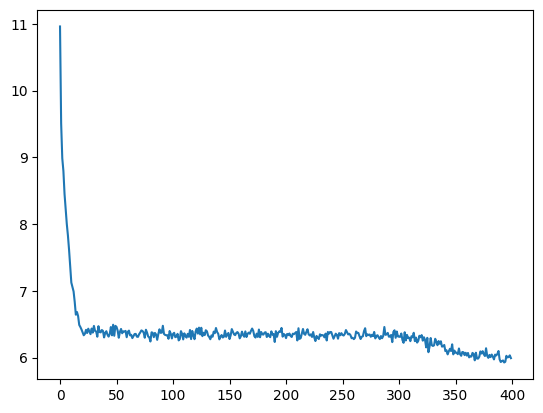

epoch : 0, step : 401, loss : 5.965643882751465, dt: 114.47ms , tok/sec: 143125.92
epoch : 0, step : 402, loss : 5.914987564086914, dt: 118.30ms , tok/sec: 138499.03
epoch : 0, step : 403, loss : 5.945854187011719, dt: 118.84ms , tok/sec: 137870.49
epoch : 0, step : 404, loss : 6.0335283279418945, dt: 118.52ms , tok/sec: 138235.74
epoch : 0, step : 405, loss : 5.938713073730469, dt: 118.09ms , tok/sec: 138744.82
epoch : 0, step : 406, loss : 5.973367691040039, dt: 118.94ms , tok/sec: 137754.13
epoch : 0, step : 407, loss : 5.984074592590332, dt: 118.19ms , tok/sec: 138629.78
epoch : 0, step : 408, loss : 5.96143913269043, dt: 119.69ms , tok/sec: 136891.12
epoch : 0, step : 409, loss : 5.952842712402344, dt: 118.57ms , tok/sec: 138177.10
epoch : 0, step : 410, loss : 5.924747467041016, dt: 119.05ms , tok/sec: 137619.51
epoch : 0, step : 411, loss : 5.947123050689697, dt: 118.99ms , tok/sec: 137690.93
epoch : 0, step : 412, loss : 5.915196895599365, dt: 119.15ms , tok/sec: 137501.65
epoc

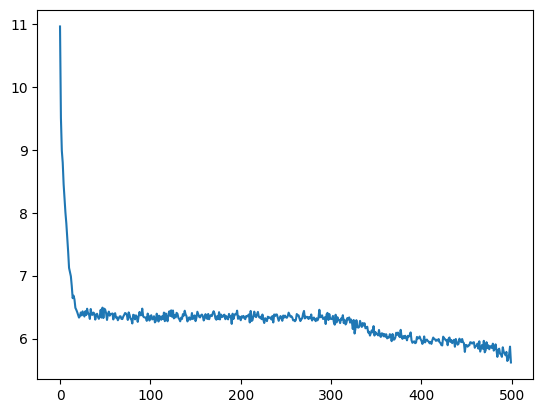

epoch : 0, step : 501, loss : 5.782941818237305, dt: 115.87ms , tok/sec: 141396.94
epoch : 0, step : 502, loss : 5.7050018310546875, dt: 119.38ms , tok/sec: 137247.08
epoch : 0, step : 503, loss : 5.701942443847656, dt: 119.75ms , tok/sec: 136819.71
epoch : 0, step : 504, loss : 5.655889511108398, dt: 119.96ms , tok/sec: 136579.87
epoch : 0, step : 505, loss : 5.66533088684082, dt: 119.12ms , tok/sec: 137536.60
epoch : 0, step : 506, loss : 5.617849826812744, dt: 119.24ms , tok/sec: 137401.31
epoch : 0, step : 507, loss : 5.744508743286133, dt: 119.26ms , tok/sec: 137381.53
epoch : 0, step : 508, loss : 5.650758743286133, dt: 119.79ms , tok/sec: 136770.96
epoch : 0, step : 509, loss : 5.728396415710449, dt: 119.93ms , tok/sec: 136618.69
epoch : 0, step : 510, loss : 5.660267353057861, dt: 119.13ms , tok/sec: 137526.70
epoch : 0, step : 511, loss : 5.659939765930176, dt: 119.08ms , tok/sec: 137588.37
epoch : 0, step : 512, loss : 5.655290603637695, dt: 119.33ms , tok/sec: 137296.71
epoc

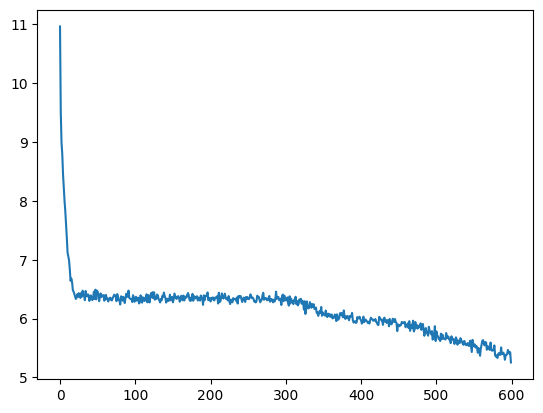

epoch : 0, step : 601, loss : 5.476187705993652, dt: 116.25ms , tok/sec: 140938.74
epoch : 0, step : 602, loss : 5.316367149353027, dt: 119.63ms , tok/sec: 136952.23
epoch : 0, step : 603, loss : 5.287306308746338, dt: 120.41ms , tok/sec: 136064.43
epoch : 0, step : 604, loss : 5.324840545654297, dt: 120.14ms , tok/sec: 136371.17
epoch : 0, step : 605, loss : 5.362994194030762, dt: 119.01ms , tok/sec: 137668.03
epoch : 0, step : 606, loss : 5.399702072143555, dt: 120.75ms , tok/sec: 135682.14
epoch : 0, step : 607, loss : 5.363350868225098, dt: 120.19ms , tok/sec: 136322.47
epoch : 0, step : 608, loss : 5.289896011352539, dt: 120.87ms , tok/sec: 135554.48
epoch : 0, step : 609, loss : 5.305340766906738, dt: 120.57ms , tok/sec: 135889.54
epoch : 0, step : 610, loss : 5.376878261566162, dt: 119.16ms , tok/sec: 137496.98
epoch : 0, step : 611, loss : 5.3535661697387695, dt: 120.17ms , tok/sec: 136335.18
epoch : 0, step : 612, loss : 5.2473554611206055, dt: 120.42ms , tok/sec: 136057.43
ep

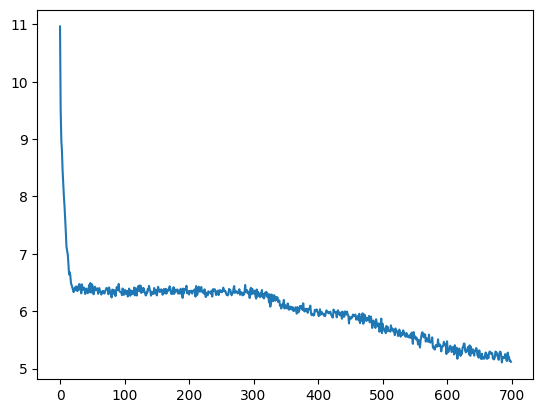

epoch : 0, step : 701, loss : 5.157771110534668, dt: 116.95ms , tok/sec: 140094.87
epoch : 0, step : 702, loss : 5.084015369415283, dt: 120.14ms , tok/sec: 136379.56
epoch : 0, step : 703, loss : 5.15226411819458, dt: 119.77ms , tok/sec: 136796.28
epoch : 0, step : 704, loss : 5.163610458374023, dt: 120.04ms , tok/sec: 136483.03
epoch : 0, step : 705, loss : 5.070159435272217, dt: 120.01ms , tok/sec: 136518.27
epoch : 0, step : 706, loss : 5.19294548034668, dt: 119.39ms , tok/sec: 137235.02
epoch : 0, step : 707, loss : 5.03575325012207, dt: 120.30ms , tok/sec: 136191.98
epoch : 0, step : 708, loss : 5.102275848388672, dt: 120.51ms , tok/sec: 135957.56
epoch : 0, step : 709, loss : 5.170598983764648, dt: 119.94ms , tok/sec: 136599.14
epoch : 0, step : 710, loss : 5.247833728790283, dt: 119.84ms , tok/sec: 136717.63
epoch : 0, step : 711, loss : 5.072965145111084, dt: 119.89ms , tok/sec: 136655.64
epoch : 0, step : 712, loss : 5.096588134765625, dt: 120.45ms , tok/sec: 136019.45
epoch :

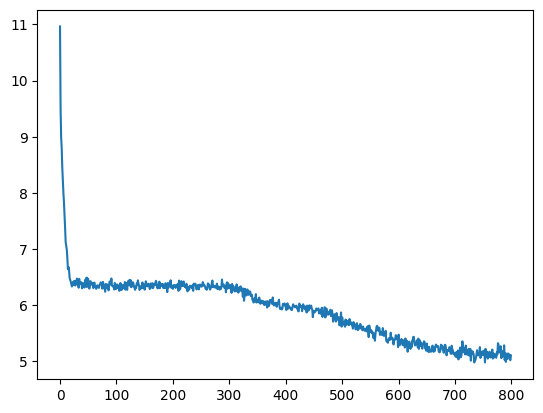

epoch : 0, step : 801, loss : 5.026058197021484, dt: 116.42ms , tok/sec: 140731.80
epoch : 0, step : 802, loss : 4.989933490753174, dt: 119.99ms , tok/sec: 136545.94
epoch : 0, step : 803, loss : 5.083779811859131, dt: 120.28ms , tok/sec: 136211.42
epoch : 0, step : 804, loss : 5.047878265380859, dt: 120.13ms , tok/sec: 136386.87
epoch : 0, step : 805, loss : 5.034334659576416, dt: 120.72ms , tok/sec: 135715.37
epoch : 0, step : 806, loss : 5.06170654296875, dt: 121.18ms , tok/sec: 135206.42
epoch : 0, step : 807, loss : 5.084065914154053, dt: 119.96ms , tok/sec: 136580.95
epoch : 0, step : 808, loss : 5.0464324951171875, dt: 121.67ms , tok/sec: 134655.89
epoch : 0, step : 809, loss : 5.056105613708496, dt: 120.21ms , tok/sec: 136289.49
epoch : 0, step : 810, loss : 5.014750957489014, dt: 120.68ms , tok/sec: 135767.92
epoch : 0, step : 811, loss : 5.0880961418151855, dt: 120.05ms , tok/sec: 136472.46
epoch : 0, step : 812, loss : 5.096083641052246, dt: 120.52ms , tok/sec: 135940.62
epo

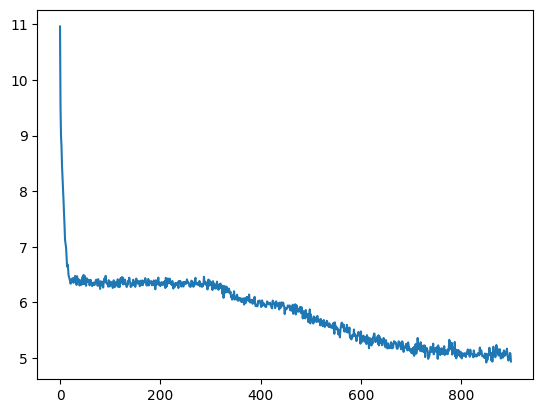

epoch : 0, step : 901, loss : 5.0592451095581055, dt: 116.86ms , tok/sec: 140205.49
epoch : 0, step : 902, loss : 5.004966735839844, dt: 120.68ms , tok/sec: 135767.65
epoch : 0, step : 903, loss : 5.084035873413086, dt: 120.29ms , tok/sec: 136206.56
epoch : 0, step : 904, loss : 5.126828193664551, dt: 120.10ms , tok/sec: 136418.27
epoch : 0, step : 905, loss : 5.0739827156066895, dt: 120.43ms , tok/sec: 136042.07
epoch : 0, step : 906, loss : 4.946743011474609, dt: 120.57ms , tok/sec: 135890.62
epoch : 0, step : 907, loss : 4.988520622253418, dt: 120.36ms , tok/sec: 136129.66
epoch : 0, step : 908, loss : 4.995355606079102, dt: 120.68ms , tok/sec: 135769.53
epoch : 0, step : 909, loss : 4.948387145996094, dt: 120.06ms , tok/sec: 136463.24
epoch : 0, step : 910, loss : 5.075133323669434, dt: 120.85ms , tok/sec: 135577.21
epoch : 0, step : 911, loss : 5.043784141540527, dt: 120.21ms , tok/sec: 136299.76
epoch : 0, step : 912, loss : 5.079622745513916, dt: 120.91ms , tok/sec: 135503.42
ep

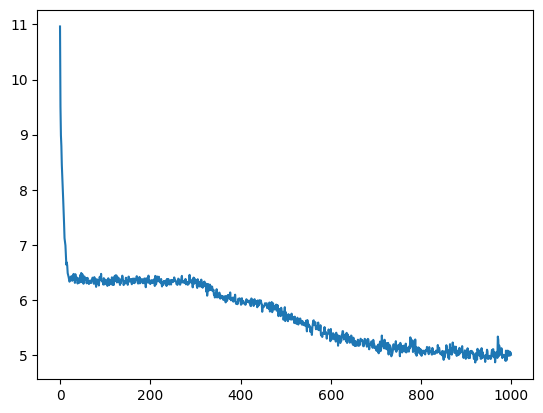

epoch : 0, step : 1001, loss : 4.988830089569092, dt: 117.66ms , tok/sec: 139253.14
epoch : 0, step : 1002, loss : 4.908609390258789, dt: 120.26ms , tok/sec: 136243.28
epoch : 0, step : 1003, loss : 4.9561285972595215, dt: 120.60ms , tok/sec: 135859.45
epoch : 0, step : 1004, loss : 4.989662170410156, dt: 120.62ms , tok/sec: 135826.96
epoch : 0, step : 1005, loss : 5.0754194259643555, dt: 120.51ms , tok/sec: 135955.41
epoch : 0, step : 1006, loss : 5.067080974578857, dt: 120.70ms , tok/sec: 135740.57
epoch : 0, step : 1007, loss : 4.9336042404174805, dt: 120.47ms , tok/sec: 136002.23
epoch : 0, step : 1008, loss : 4.892078399658203, dt: 121.08ms , tok/sec: 135320.64
epoch : 0, step : 1009, loss : 5.007442474365234, dt: 120.56ms , tok/sec: 135899.48
epoch : 0, step : 1010, loss : 4.887876033782959, dt: 121.08ms , tok/sec: 135317.18
epoch : 0, step : 1011, loss : 4.898331642150879, dt: 121.05ms , tok/sec: 135351.30
epoch : 0, step : 1012, loss : 4.91599178314209, dt: 120.52ms , tok/sec: 

In [ ]:
losses = []
num_epochs=1
model.to(GPTConfig.device)
for epoch in range(num_epochs):
  i=0
  for x,y in trainDataLoader:
    i+=1
    t0 = time.time()
    optimizer.zero_grad()
    x = x.to(GPTConfig.device)
    y = y.to(GPTConfig.device)
    with torch.autocast(device_type=GPTConfig.device, dtype =torch.bfloat16):
      logits, loss = model(x,y)
    loss_val = loss.item()
    losses.append(loss_val)
    loss.backward()
    optimizer.step()
    torch.cuda.synchronize()
    t1 = time.time()
    dt = (t1-t0)*1000
    tokens_per_sec = (batch_size*GPTConfig.block_size)/(t1-t0)
    print(f"epoch : {epoch}, step : {i}, loss : {loss_val}, dt: {dt:.2f}ms , tok/sec: {tokens_per_sec:.2f}")
    # plot loss graph every 100 steps.
    if(i%100 == 0):
      plt.plot(losses)
      plt.show()

In [ ]:
num_return_sequences = 5
max_length = 30
model.eval() # this removes things like dropouts
model.to('cuda')
tokens = get_tokens("Hello, I'm a language model")
tokens = tokens.unsqueeze(0).repeat(num_return_sequences,1) # repeat along the dim1
x = tokens.to('cuda')
torch.manual_seed(42)
torch.cuda.manual_seed(42)
print(x.shape)
while x.size(1) < max_length:
  with torch.no_grad():
    logits = model(x) # B,T,vocab_size
    logits = logits[:,-1,:] # B,vocab_size. Only need the last logits
    probs = F.softmax(logits,dim=-1)
    # we pick only top50, so that hte model doesn't stray away into unkonwn zones. and styas in "good" zones
    topk_probs, topk_indices = torch.topk(probs,50,dim=-1) # this is the temperature sampling essentially. we don't pick the most probable, rather we sample from the distribution
    ix = torch.multinomial(topk_probs,1)#B,1
    xcol = torch.gather(topk_indices,-1,ix)
    x = torch.cat((x,xcol),dim=1)

for i in range(num_return_sequences):
  tokens = x[i,:max_length].tolist()
  print(">",get_text(tokens))